## Spark Session Build

In [ ]:
#importing pyspark
import pyspark
#importing sparksession
from pyspark.sql import SparkSession
#creating a sparksession object and providing appName
spark=SparkSession.builder \
.master("local") \
.appName("CSCI-316 Project") \
.config('spark.ui.port','4050') \
.getOrCreate()

# Property used to format output tables better
spark.conf.set("spark.sql.repl.eagerEval.enabled", True)
#printing the version of spark
print("Apache Spark version: ", spark.version)
spark

Apache Spark version:  3.5.4


## Loading Data

In [ ]:
#get the dataset
!wget -q https://www.dubaipulse.gov.ae/dataset/c9263194-5ee3-4340-b7c0-3269b26acb43/resource/c3ece154-3071-4116-8650-e769d8416d88/download/traffic_incidents.csv

In [ ]:
df = spark.read.csv('traffic_incidents.csv', header=True, inferSchema=True)

In [ ]:
df.show(truncate=False)

NameError: name 'df' is not defined

In [ ]:
df.describe().show()

+-------+-------------------+-------------------+--------------------+-------------------+-------------------+
|summary|            acci_id|          acci_time|           acci_name|             acci_x|             acci_y|
+-------+-------------------+-------------------+--------------------+-------------------+-------------------+
|  count|              31903|              31903|               31903|              31903|              31903|
|   mean|5.915852967962167E9|               NULL|                NULL|  25.15134666716816| 55.296795045508645|
| stddev|5.348964584489998E8|               NULL|                NULL|0.17781170587791978|0.20219180245154114|
|    min|         4245262601|01/01/2025 00:04:02|ازدحام في المنافذ...|                0.0|        35.93452656|
|    max|         6213991949|31/12/2024 23:30:54|وجود جسم في الشار...|        31.94759659|        77.21667027|
+-------+-------------------+-------------------+--------------------+-------------------+-------------------+



In [ ]:
#print schema
df.printSchema()


root
 |-- acci_id: long (nullable = true)
 |-- acci_time: string (nullable = true)
 |-- acci_name: string (nullable = true)
 |-- acci_x: double (nullable = true)
 |-- acci_y: double (nullable = true)



## Pre-Proccessing data

In [ ]:
#drop null values
df = df.dropna()

In [ ]:
#check for null values
from pyspark.sql.functions import *
df.select([sum(col(c).isNull().cast("int")).alias(c) for c in df.columns]).show()

+-------+---------+---------+------+------+
|acci_id|acci_time|acci_name|acci_x|acci_y|
+-------+---------+---------+------+------+
|      0|        0|        0|     0|     0|
+-------+---------+---------+------+------+



In [ ]:
#renaming columns
df = df.withColumnRenamed("acci_id", "Accident_ID") \
       .withColumnRenamed("acci_time", "Accident_Time") \
       .withColumnRenamed("acci_name", "Accident_Name") \
       .withColumnRenamed("acci_x", "Latitude") \
       .withColumnRenamed("acci_y", "Longitude")

In [ ]:
#convert the acci_time column to a timestamp datatype

df = df.withColumn("Accident_Time", to_timestamp("Accident_Time", "dd/MM/yyyy HH:mm:ss"))
df.show(truncate=False)


+-----------+-------------------+--------------------------------------------------+-----------+-----------+
|Accident_ID|Accident_Time      |Accident_Name                                     |Latitude   |Longitude  |
+-----------+-------------------+--------------------------------------------------+-----------+-----------+
|6213809256 |2025-02-07 06:45:49|تعطل مركبة خفيفة - بسيط                           |25.19527089|55.30924037|
|6213878659 |2025-02-07 07:13:16|صدم حاجز - بسيط                                   |25.10597999|55.1779    |
|6213881808 |2025-02-07 07:14:22|اصطدام بين عدة مركبات - بسيط                      |25.03956   |55.19211999|
|6213929945 |2025-02-07 07:31:51|صدم حاجز - بسيط                                   |25.3159102 |55.34578776|
|6213941263 |2025-02-07 07:36:01|الوقوف خلف المركبات (دبل بارك) - بسيط             |25.09382678|55.31791082|
|6213959880 |2025-02-07 07:42:37|تعطل مركبة خفيفة - بسيط                           |25.16305497|55.23277696|
|6213974804 |2025-0

In [ ]:
#check the time datatype
df.printSchema()

root
 |-- Accident_ID: long (nullable = true)
 |-- Accident_Time: timestamp (nullable = true)
 |-- Accident_Name: string (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)



In [ ]:
#Extract Hour & Weekday
df = df.withColumn("Hour", hour("Accident_Time"))
df = df.withColumn("Weekday", date_format("Accident_Time",'EEEE'))
df.show(truncate=False)


+-----------+-------------------+--------------------------------------------------+-----------+-----------+----+-------+
|Accident_ID|Accident_Time      |Accident_Name                                     |Latitude   |Longitude  |Hour|Weekday|
+-----------+-------------------+--------------------------------------------------+-----------+-----------+----+-------+
|6213809256 |2025-02-07 06:45:49|تعطل مركبة خفيفة - بسيط                           |25.19527089|55.30924037|6   |Friday |
|6213878659 |2025-02-07 07:13:16|صدم حاجز - بسيط                                   |25.10597999|55.1779    |7   |Friday |
|6213881808 |2025-02-07 07:14:22|اصطدام بين عدة مركبات - بسيط                      |25.03956   |55.19211999|7   |Friday |
|6213929945 |2025-02-07 07:31:51|صدم حاجز - بسيط                                   |25.3159102 |55.34578776|7   |Friday |
|6213941263 |2025-02-07 07:36:01|الوقوف خلف المركبات (دبل بارك) - بسيط             |25.09382678|55.31791082|7   |Friday |
|6213959880 |2025-02-07 

In [ ]:
df.select("Accident_Time", "Hour", "Weekday").show(300, truncate=False)


+-------------------+----+--------+
|Accident_Time      |Hour|Weekday |
+-------------------+----+--------+
|2025-02-07 06:45:49|6   |Friday  |
|2025-02-07 07:13:16|7   |Friday  |
|2025-02-07 07:14:22|7   |Friday  |
|2025-02-07 07:31:51|7   |Friday  |
|2025-02-07 07:36:01|7   |Friday  |
|2025-02-07 07:42:37|7   |Friday  |
|2025-02-07 07:48:07|7   |Friday  |
|2025-02-07 07:49:05|7   |Friday  |
|2025-02-07 07:50:35|7   |Friday  |
|2025-02-07 07:54:21|7   |Friday  |
|2025-02-07 00:35:22|0   |Friday  |
|2025-02-07 06:13:52|6   |Friday  |
|2025-02-07 05:52:53|5   |Friday  |
|2025-02-07 06:13:56|6   |Friday  |
|2025-02-07 07:29:51|7   |Friday  |
|2025-02-07 05:00:00|5   |Friday  |
|2025-02-07 06:21:08|6   |Friday  |
|2025-02-07 05:27:05|5   |Friday  |
|2025-02-07 05:55:17|5   |Friday  |
|2025-02-07 04:38:01|4   |Friday  |
|2025-02-07 04:19:37|4   |Friday  |
|2025-02-07 04:41:46|4   |Friday  |
|2025-02-07 04:46:49|4   |Friday  |
|2025-02-07 03:59:24|3   |Friday  |
|2025-02-07 03:28:48|3   |Fr

In [ ]:
#Extract Severity and Incident Type

# Extract the main incident type (before "-")
df = df.withColumn("Incident_Type", regexp_extract(df["Accident_Name"], r"^(.*?)\s-\s", 1))

# Extract Severity (after "-") and map to numeric values
df = df.withColumn("Severity", regexp_extract(df["Accident_Name"], r"-\s(.*)", 1))

# Convert Severity to numeric (بسيط = 0, بليغ = 1)
df = df.withColumn("Severity",
                   when(df["Severity"] == "بسيط", 0)
                   .when(df["Severity"] == "بليغ", 1)
                   .otherwise(None))

In [ ]:
df.show(truncate=False)


+-----------+-------------------+--------------------------------------------------+-----------+-----------+----+-------+-------------------------------------------+--------+
|Accident_ID|Accident_Time      |Accident_Name                                     |Latitude   |Longitude  |Hour|Weekday|Incident_Type                              |Severity|
+-----------+-------------------+--------------------------------------------------+-----------+-----------+----+-------+-------------------------------------------+--------+
|6213809256 |2025-02-07 06:45:49|تعطل مركبة خفيفة - بسيط                           |25.19527089|55.30924037|6   |Friday |تعطل مركبة خفيفة                           |0       |
|6213878659 |2025-02-07 07:13:16|صدم حاجز - بسيط                                   |25.10597999|55.1779    |7   |Friday |صدم حاجز                                   |0       |
|6213881808 |2025-02-07 07:14:22|اصطدام بين عدة مركبات - بسيط                      |25.03956   |55.19211999|7   |Friday |اصطد

In [ ]:
df.printSchema()

root
 |-- Accident_ID: long (nullable = true)
 |-- Accident_Time: timestamp (nullable = true)
 |-- Accident_Name: string (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Hour: integer (nullable = true)
 |-- Weekday: string (nullable = true)
 |-- Incident_Type: string (nullable = true)
 |-- Severity: integer (nullable = true)



In [ ]:

df = df.withColumn("Weekday_Num", dayofweek(col("Accident_Time")))
df.show(truncate=False)


+-----------+-------------------+--------------------------------------------------+-----------+-----------+----+-------+-------------------------------------------+--------+-----------+
|Accident_ID|Accident_Time      |Accident_Name                                     |Latitude   |Longitude  |Hour|Weekday|Incident_Type                              |Severity|Weekday_Num|
+-----------+-------------------+--------------------------------------------------+-----------+-----------+----+-------+-------------------------------------------+--------+-----------+
|6213809256 |2025-02-07 06:45:49|تعطل مركبة خفيفة - بسيط                           |25.19527089|55.30924037|6   |Friday |تعطل مركبة خفيفة                           |0       |6          |
|6213878659 |2025-02-07 07:13:16|صدم حاجز - بسيط                                   |25.10597999|55.1779    |7   |Friday |صدم حاجز                                   |0       |6          |
|6213881808 |2025-02-07 07:14:22|اصطدام بين عدة مركبات - بسيط    

In [ ]:
numerical_cols = ["Hour", "Weekday_num", "Latitude", "Longitude", "Severity"]

for col1 in numerical_cols:
    for col2 in numerical_cols:
        if col1 != col2:
            try:
                corr_value = df.stat.corr(col1, col2)
                print(f"Correlation between {col1} and {col2}: {corr_value:.3f}")
            except Exception as e:
                print(f"Error in {col1} vs {col2}: {e}")


Correlation between Hour and Weekday_num: -0.005
Correlation between Hour and Latitude: 0.003
Correlation between Hour and Longitude: 0.012
Correlation between Hour and Severity: 0.028
Correlation between Weekday_num and Hour: -0.005
Correlation between Weekday_num and Latitude: -0.012
Correlation between Weekday_num and Longitude: -0.012
Correlation between Weekday_num and Severity: -0.005
Correlation between Latitude and Hour: 0.003
Correlation between Latitude and Weekday_num: -0.012
Correlation between Latitude and Longitude: 0.174
Correlation between Latitude and Severity: -0.005
Correlation between Longitude and Hour: 0.012
Correlation between Longitude and Weekday_num: -0.012
Correlation between Longitude and Latitude: 0.174
Correlation between Longitude and Severity: -0.004
Correlation between Severity and Hour: 0.028
Correlation between Severity and Weekday_num: -0.005
Correlation between Severity and Latitude: -0.005
Correlation between Severity and Longitude: -0.004


In [ ]:
df_cleaned = df.select("Hour", "Weekday_Num","Accident_Time", "Latitude", "Longitude","Severity")
df_cleaned.show(truncate=False)

+----+-----------+-------------------+-----------+-----------+--------+
|Hour|Weekday_Num|Accident_Time      |Latitude   |Longitude  |Severity|
+----+-----------+-------------------+-----------+-----------+--------+
|6   |6          |2025-02-07 06:45:49|25.19527089|55.30924037|0       |
|7   |6          |2025-02-07 07:13:16|25.10597999|55.1779    |0       |
|7   |6          |2025-02-07 07:14:22|25.03956   |55.19211999|0       |
|7   |6          |2025-02-07 07:31:51|25.3159102 |55.34578776|0       |
|7   |6          |2025-02-07 07:36:01|25.09382678|55.31791082|0       |
|7   |6          |2025-02-07 07:42:37|25.16305497|55.23277696|0       |
|7   |6          |2025-02-07 07:48:07|25.00897999|55.09671   |0       |
|7   |6          |2025-02-07 07:49:05|25.11012185|55.19424944|NULL    |
|7   |6          |2025-02-07 07:50:35|25.26119   |55.33672999|0       |
|7   |6          |2025-02-07 07:54:21|25.25244302|55.37032851|0       |
|0   |6          |2025-02-07 00:35:22|24.96643852|55.13953046|0 

In [ ]:
#check for null values
from pyspark.sql.functions import *
df_cleaned.select([sum(col(c).isNull().cast("int")).alias(c) for c in df_cleaned.columns]).show()

+----+-----------+-------------+--------+---------+--------+
|Hour|Weekday_Num|Accident_Time|Latitude|Longitude|Severity|
+----+-----------+-------------+--------+---------+--------+
|   0|          0|            0|       0|        0|    2266|
+----+-----------+-------------+--------+---------+--------+



In [ ]:
#drop all the null values in the severity column in df_cleaned

df_cleaned = df_cleaned.dropna(subset=["Severity"])
df_cleaned.select([sum(col(c).isNull().cast("int")).alias(c) for c in df_cleaned.columns]).show()


+----+-----------+-------------+--------+---------+--------+
|Hour|Weekday_Num|Accident_Time|Latitude|Longitude|Severity|
+----+-----------+-------------+--------+---------+--------+
|   0|          0|            0|       0|        0|       0|
+----+-----------+-------------+--------+---------+--------+



In [ ]:
from pyspark.ml.feature import VectorAssembler

# Select the features for X
assembler = VectorAssembler(inputCols=["Hour", "Weekday_Num", "Latitude", "Longitude"], outputCol="features")
X = assembler.transform(df_cleaned).select("features")

# Select the target variable for Y
Y = df_cleaned.select("Severity")

### Pipeline

In [ ]:
from sklearn.preprocessing import StandardScaler
from pyspark.sql.functions import udf
from pyspark.sql.types import ArrayType, DoubleType
import numpy as np

to_array = udf(lambda v: v.toArray().tolist(), ArrayType(DoubleType()))

# Apply the UDF to the 'features' column
X = X.withColumn("features_array", to_array("features"))

# Convert to pandas DataFrame for compatibility with StandardScaler
X_pd = X.select("features_array").toPandas()

# Extract the NumPy array from the pandas DataFrame
X_np = X_pd['features_array'].apply(np.array).values

scaler = StandardScaler()
X = scaler.fit_transform(X_np.tolist())

In [ ]:
import pandas as pd
X_scaled_pd = pd.DataFrame(X, columns=["Hour_scaled", "Weekday_Num_scaled", "Latitude_scaled", "Longitude_scaled"])
# X_scaled_spark = spark.createDataFrame(X_scaled_pd)

In [ ]:
X_scaled_pd.head()

,Hour_scaled,Weekday_Num_scaled,Latitude_scaled,Longitude_scaled
0,-1.196779,1.028502,0.252405,0.066644
1,-1.032272,1.028502,-0.236282,-0.565900
2,-1.032272,1.028502,-0.599798,-0.497416
3,-1.032272,1.028502,0.912663,0.242659
4,-1.032272,1.028502,-0.302797,0.108402


In [ ]:
Y_np = Y.toPandas()['Severity'].values


In [ ]:
# from imblearn.under_sampling import RandomUnderSampler

# rus = RandomUnderSampler(random_state=42)
# X_train_resampled, Y_train_resampled = rus.fit_resample(X_train, Y_train)

In [ ]:
import pandas as pd
# deopped Weekday_Num_scaled  because its ot a good feature for the model
X_scaled_pd = X_scaled_pd.drop(columns=["Weekday_Num_scaled"])
X_scaled_pd.head()


,Hour_scaled,Latitude_scaled,Longitude_scaled
0,-1.196779,0.252405,0.066644
1,-1.032272,-0.236282,-0.565900
2,-1.032272,-0.599798,-0.497416
3,-1.032272,0.912663,0.242659
4,-1.032272,-0.302797,0.108402


###  Visualizing distribution of features for different classes

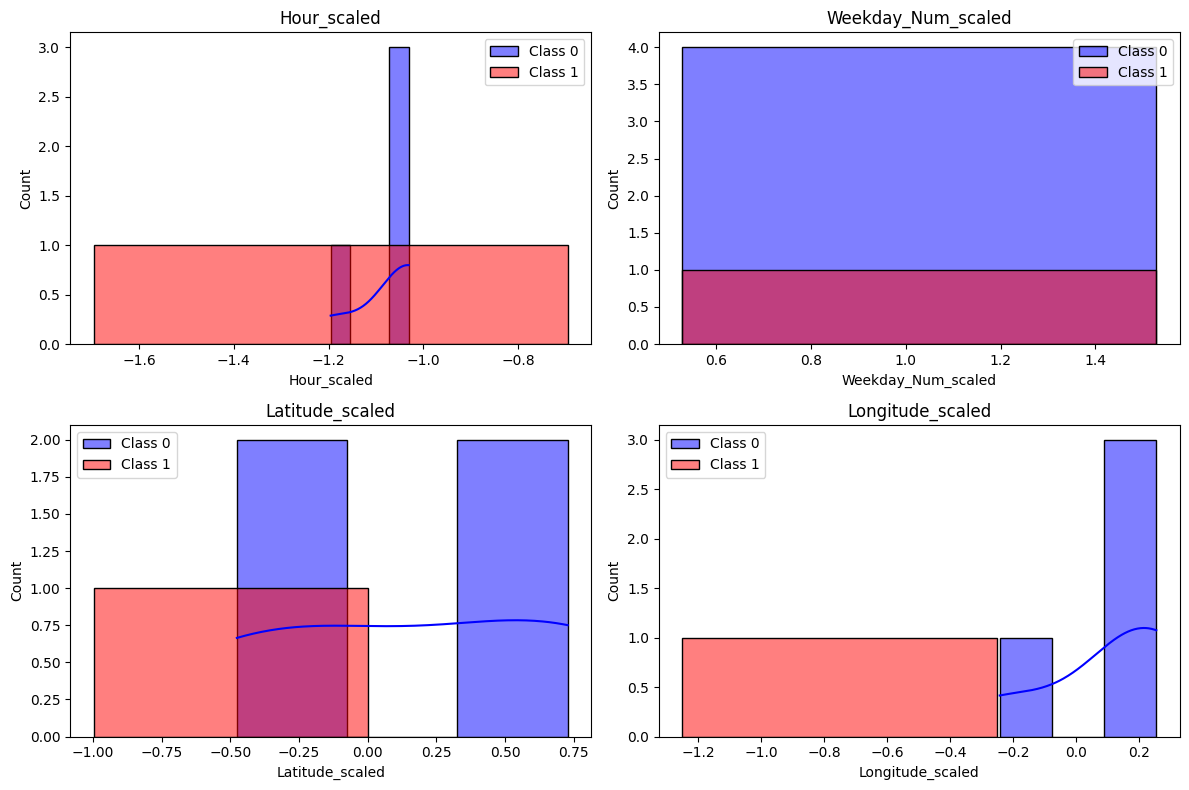

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Sample data (replace with your actual data)
data = {
    "Hour_scaled": [-1.195518, -1.195518, -1.031059, -1.031059, -1.031059],
    "Weekday_Num_scaled": [1.028502, 1.028502, 1.028502, 1.028502, 1.028502],
    "Latitude_scaled": [0.662384, -0.497458, -0.195335, -0.476450, 0.727604],
    "Longitude_scaled": [0.164492, -0.750231, 0.256085, -0.241630, 0.245586],
    "Severity": [0, 1, 0, 0, 0]
}

df3 = pd.DataFrame(data)

# Separate classes
class_0 = df3[df3["Severity"] == 0]
class_1 = df3[df3["Severity"] == 1]

# Features to plot (including 'Weekday_Num_scaled')
features_to_plot = ["Hour_scaled", "Weekday_Num_scaled", "Latitude_scaled", "Longitude_scaled"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # 2x2 grid for 4 features
axes = axes.flatten()  # Flatten the axes array for easier indexing

for i, feature in enumerate(features_to_plot):
    ax = axes[i]  # Access axes using index
    sns.histplot(class_0[feature], label="Class 0", color="blue", kde=True, ax=ax, alpha=0.5)
    sns.histplot(class_1[feature], label="Class 1", color="red", kde=True, ax=ax, alpha=0.5)
    ax.set_title(feature)
    ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
X = X_scaled_pd
y = Y_np
X.head()
y_pd = pd.DataFrame(y, columns=['Severity'])

# Display the first few rows using pandas head()
y_pd.head()

,Severity
0,0
1,0
2,0
3,0
4,0


In [ ]:
y_pd.value_counts()

,count
Severity,
0,26504
1,3133


## Ensemble Model


### Model Development Common function (boostrap, SMOTEENN)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.combine import SMOTEENN
from scipy.stats import mode

# --------------------------
# Data Preparation & Class Imbalance Handling
# --------------------------
def prepare_data(X, y, test_size=0.2, random_state=42):
    """
    Split the data into training and testing sets and address class imbalance using SMOTEENN.
    """
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    smote_enn = SMOTEENN(random_state=random_state)
    X_train_res, y_train_res = smote_enn.fit_resample(X_train, y_train)
    X_train_res = np.array(X_train_res)
    y_train_res = np.array(y_train_res)
    return X_train_res, X_test, y_train_res, y_test


# --------------------------
# Bootstrap Sampling Function
# --------------------------
def bootstrap_sample(X, y):
    """
    Create a bootstrap sample from the given DataFrame (X) and Series (y).
    """
    n_samples = X.shape[0]
    indices = np.random.choice(n_samples, size=n_samples, replace=True)
    return X[indices], y[indices]

# --------------------------
# Model Evaluation Function
# --------------------------
def evaluate_model(y_test, predictions):
    """
    Evaluate the model's performance and display the classification report and confusion matrix.
    """
    accuracy = accuracy_score(y_test, predictions)
    print("Accuracy:", accuracy)
    print("Classification Report:")
    print(classification_report(y_test, predictions))

    conf_matrix = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(10, 7))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()


In [ ]:
X_train_res, X_test, y_train_res, y_test = prepare_data(X, y)

### Dession Tree Bagging

In [69]:
# --------------------------
# Bagging Decision Tree
# --------------------------
def bagging_decision_tree(X_train, y_train, X_test, n_estimators=10):
    """
    Train an ensemble of Decision Trees using bootstrap sampling (Bagging)
    and aggregate predictions via majority voting.
    """
    predictions = []

    for _ in range(n_estimators):
        X_boot, y_boot = bootstrap_sample(X_train, y_train)
        model = DecisionTreeClassifier(class_weight="balanced", random_state=42)
        model.fit(X_boot, y_boot)
        preds = model.predict(X_test)
        predictions.append(preds)

    predictions = np.array(predictions)
    final_predictions, _ = mode(predictions, axis=0)
    return final_predictions.ravel()


Running Bagging Decision Tree...


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: U

Accuracy: 0.6961875843454791
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      5317
           1       0.12      0.30      0.17       611

    accuracy                           0.70      5928
   macro avg       0.51      0.52      0.49      5928
weighted avg       0.82      0.70      0.75      5928



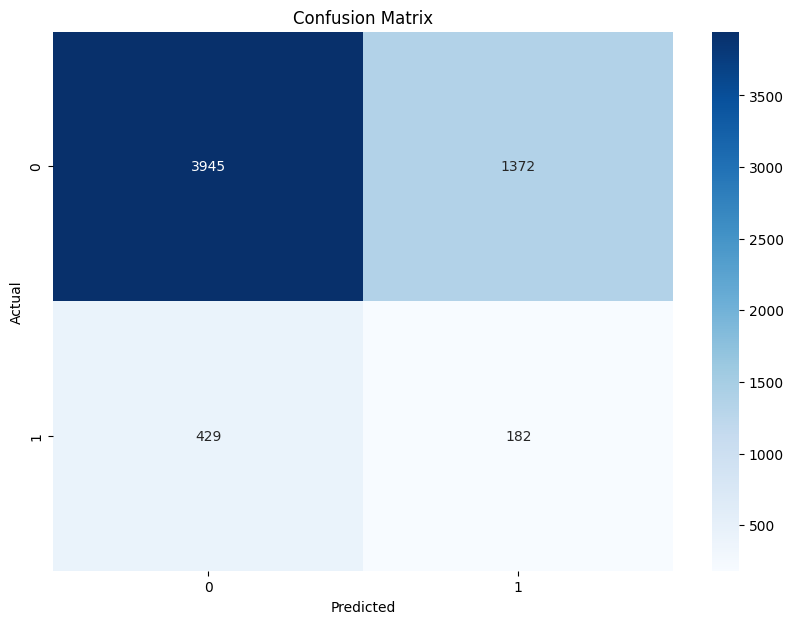

In [70]:
print("Running Bagging Decision Tree...")
bagging_preds = bagging_decision_tree(X_train_res, y_train_res, X_test, n_estimators=10)
evaluate_model(y_test, bagging_preds)

### Hetrogenous Ensemble

In [71]:
# --------------------------
# Heterogeneous Ensemble
# --------------------------
def diverse_ensemble(X_train, y_train, X_test, n_estimators=10):
    """
    Train a heterogeneous ensemble by combining predictions from different classifiers.
    """
    all_iteration_predictions = []
    base_classifiers = [
        ("dt", DecisionTreeClassifier(random_state=42, class_weight='balanced')),
        ("lr", LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)),
        ("svm", SVC(random_state=42, class_weight='balanced'))
    ]

    for i in range(n_estimators):
        X_boot, y_boot = bootstrap_sample(X_train, y_train)
        iteration_preds = []

        for name, clf in base_classifiers:
            model = clf.__class__(**clf.get_params())
            model.fit(X_boot, y_boot)
            preds = model.predict(X_test)
            iteration_preds.append(preds)

        iteration_preds = np.array(iteration_preds)
        vote, _ = mode(iteration_preds, axis=0)
        all_iteration_predictions.append(vote.ravel())

    all_iteration_predictions = np.array(all_iteration_predictions)
    final_vote, _ = mode(all_iteration_predictions, axis=0)
    return final_vote.ravel()



Running Heterogeneous Ensemble...


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature n

Accuracy: 0.5789473684210527
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.59      0.71      5317
           1       0.13      0.52      0.20       611

    accuracy                           0.58      5928
   macro avg       0.52      0.55      0.46      5928
weighted avg       0.83      0.58      0.66      5928



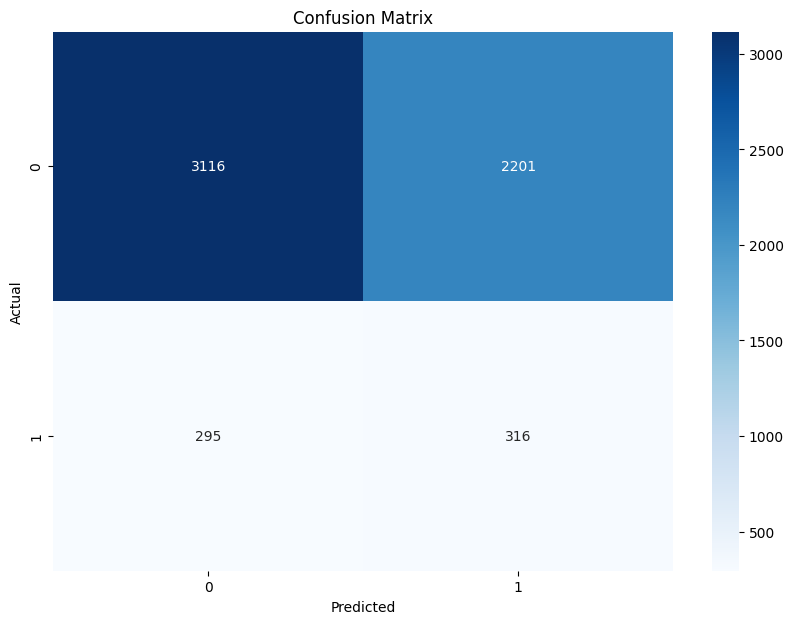

In [72]:
print("Running Heterogeneous Ensemble...")
diverse_preds = diverse_ensemble(X_train_res, y_train_res, X_test, n_estimators=10)
evaluate_model(y_test, diverse_preds)

### Heterogeneous Ensemble with Weighted Voting

In [73]:
# --------------------------
# Heterogeneous Ensemble with Weighted Voting
# --------------------------
def diverse_ensemble_weighted(X_train, y_train, X_test, n_estimators=10, classifier_weights=None):
    """
    Train a heterogeneous ensemble using weighted voting.
    """
    if classifier_weights is None:
        classifier_weights = np.array([0.4, 0.3, 0.3])
    else:
        classifier_weights = np.array(classifier_weights)

    all_iteration_predictions = []
    base_classifiers = [
        ("dt", DecisionTreeClassifier(random_state=42, class_weight='balanced')),
        ("lr", LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)),
        ("svm", SVC(random_state=42, class_weight='balanced'))
    ]

    for i in range(n_estimators):
        X_boot, y_boot = bootstrap_sample(X_train, y_train)
        iteration_preds = []

        for name, clf in base_classifiers:
            model = clf.__class__(**clf.get_params())
            model.fit(X_boot, y_boot)
            preds = model.predict(X_test)
            iteration_preds.append(preds)

        iteration_preds = np.array(iteration_preds)
        weighted_sum = np.sum(classifier_weights[:, None] * iteration_preds, axis=0)
        iteration_final = (weighted_sum >= 0.5).astype(int)
        all_iteration_predictions.append(iteration_final)

    all_iteration_predictions = np.array(all_iteration_predictions)
    final_vote, _ = mode(all_iteration_predictions, axis=0)
    return final_vote.ravel()


Running Heterogeneous Ensemble with Weighted Voting...


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature n

Accuracy: 0.5804655870445344
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.59      0.72      5317
           1       0.12      0.50      0.20       611

    accuracy                           0.58      5928
   macro avg       0.52      0.55      0.46      5928
weighted avg       0.83      0.58      0.66      5928



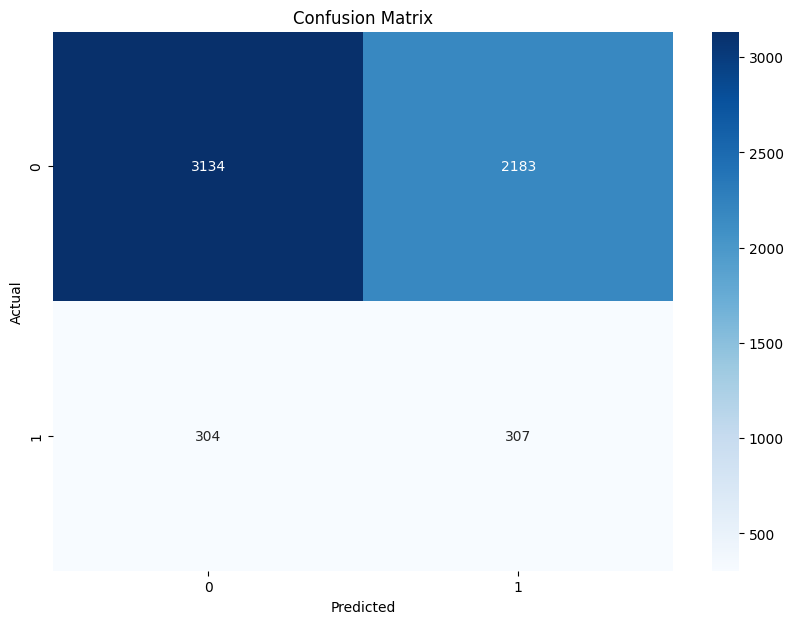

In [74]:
print("Running Heterogeneous Ensemble with Weighted Voting...")
diverse_weighted_preds = diverse_ensemble_weighted(X_train_res, y_train_res, X_test, n_estimators=10)
evaluate_model(y_test, diverse_weighted_preds)

### Bagging with SVC

Accuracy: 0.4434885290148448
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.42      0.58      5317
           1       0.11      0.64      0.19       611

    accuracy                           0.44      5928
   macro avg       0.51      0.53      0.38      5928
weighted avg       0.83      0.44      0.54      5928



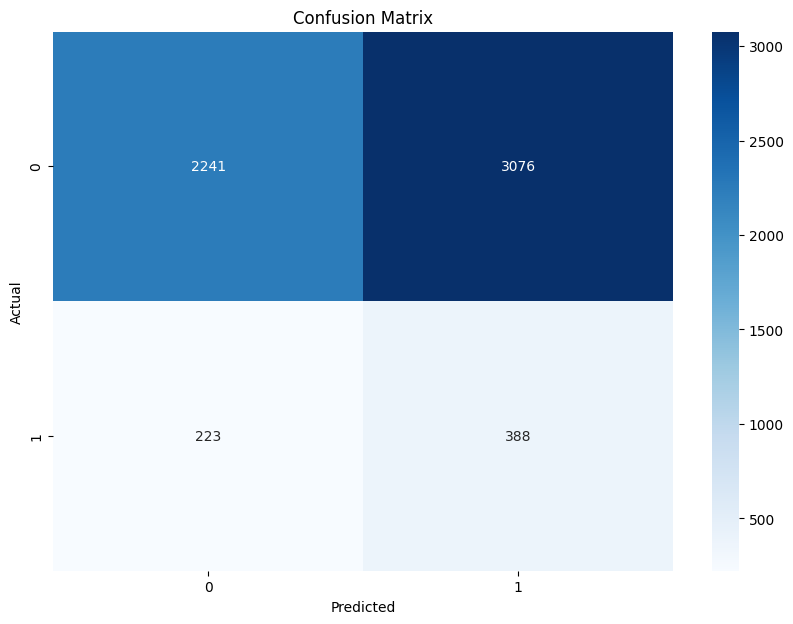

In [ ]:
def simple_svc_bagging(X_train, y_train, X_test, n_estimators=5):
    """
    Simple Bagging with SVC.
    Trains multiple SVC models on bootstrapped samples and aggregates predictions.
    """

    bagged_preds = np.zeros((n_estimators, len(X_test)), dtype=int)

    for i in range(n_estimators):
        X_boot, y_boot = bootstrap_sample(X_train, y_train)  # bootstrap sample
        model = SVC(kernel='linear', class_weight='balanced', random_state=i)  # SVC model
        model.fit(X_boot, y_boot)  # train on bootstrap sample
        bagged_preds[i] = model.predict(X_test)  # predict test set

    # majority vote across all models
    final_preds = mode(bagged_preds, axis=0, keepdims=True)[0].ravel()
    return final_preds
bagged_preds = simple_svc_bagging(X_train_res, y_train_res, X_test, n_estimators=5)
evaluate_model(y_test, bagged_preds)

## **10 CROSS VALIDATION**

### Validation Functions

In [75]:
def k_fold_split(X, y, k=10):

    indices = np.arange(len(X))
    np.random.shuffle(indices)
    folds = np.array_split(indices, k)
    return folds

def evaluate_ensemble(model, X, y, k=10, n_estimators=10):

    X = np.array(X)
    y = np.array(y)
    folds = k_fold_split(X, y, k)
    scores = []

    for i in range(k):
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])
        test_idx = folds[i]

        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]

        y_pred = model(X_train, y_train, X_test, n_estimators)
        accuracy = np.mean(y_pred == y_test)
        scores.append(accuracy)

    return np.mean(scores), np.std(scores)



### Bagging Decision Tree 10-fold Cross Validation



In [76]:
mean_acc, std_acc = evaluate_ensemble(bagging_decision_tree, X_train_res, y_train_res, k=10, n_estimators=10)
print("Bagging Decision Tree: ")
print(f"10-Fold Cross-Validation - Mean Accuracy: {mean_acc:.4f}, Standard Deviation: {std_acc:.4f}")

Bagging Decision Tree: 
10-Fold Cross-Validation - Mean Accuracy: 0.9453, Standard Deviation: 0.0032


### Heterogeneous Ensemble Cross Validation

In [ ]:
mean_acc, std_acc = evaluate_ensemble(diverse_ensemble, X_train_res, y_train_res, k=10, n_estimators=10)
print("Heterogeneous Ensemble: ")
print(f"10-Fold Cross-Validation - Mean Accuracy: {mean_acc:.4f}, Standard Deviation: {std_acc:.4f}")

### Heterogeneous Ensemble with Weighted Voting Cross Validation

In [ ]:
mean_acc, std_acc = evaluate_ensemble(diverse_ensemble_weighted, X_train_res, y_train_res, k=10, n_estimators=10)
print("Heterogeneous Ensemble with Weighted Voting: ")
print(f"10-Fold Cross-Validation - Mean Accuracy: {mean_acc:.4f}, Standard Deviation: {std_acc:.4f}")

In [78]:
mean_acc, std_acc = evaluate_ensemble(simple_svc_bagging, X_train_res, y_train_res, k=10, n_estimators=10)
print("Simple SVC bagging: ")
print(f"10-Fold Cross-Validation - Mean Accuracy: {mean_acc:.4f}, Standard Deviation: {std_acc:.4f}")

Simple SVC bagging: 
10-Fold Cross-Validation - Mean Accuracy: 0.5403, Standard Deviation: 0.0061
